In [1]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Import modules
from f_dataset import SegmentationDataset
from f_dataset import augment

#
###

In [5]:
###############
## LOAD DATA ##
###############

## Parameters
path_to_dataset = '/Users/user/Documents/projects/GlandSeg/data/SEGG/images/train_tiles/'
thresholds = np.array([0, 150, 210, 255])
# thresholds = np.array([0, 150, 255])
batch_size = 1

## Create dataset and dataloader
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=augment)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

def mps_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)
        x = x.astype('uint8')        
        images += [x]        
    return images

## Example of iterating through the DataLoader
images = []
masks = []
k = 0
with torch.no_grad():
    for X, Y in dataloader:        

        ## Inputs
        images += [mps_to_numpy(X)[0]]
        
        ## Target
        Y = Y[:, None, :, :]
        masks += [mps_to_numpy(Y)[0]]        
        
        k += 1
        if k > 16:
            break

#
###

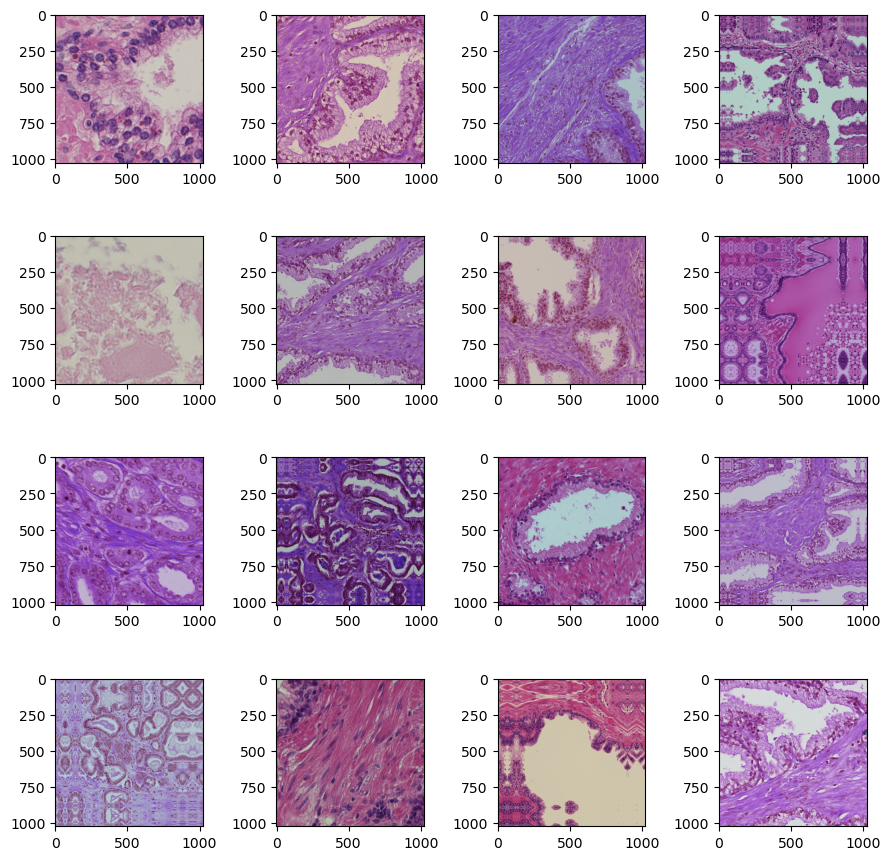

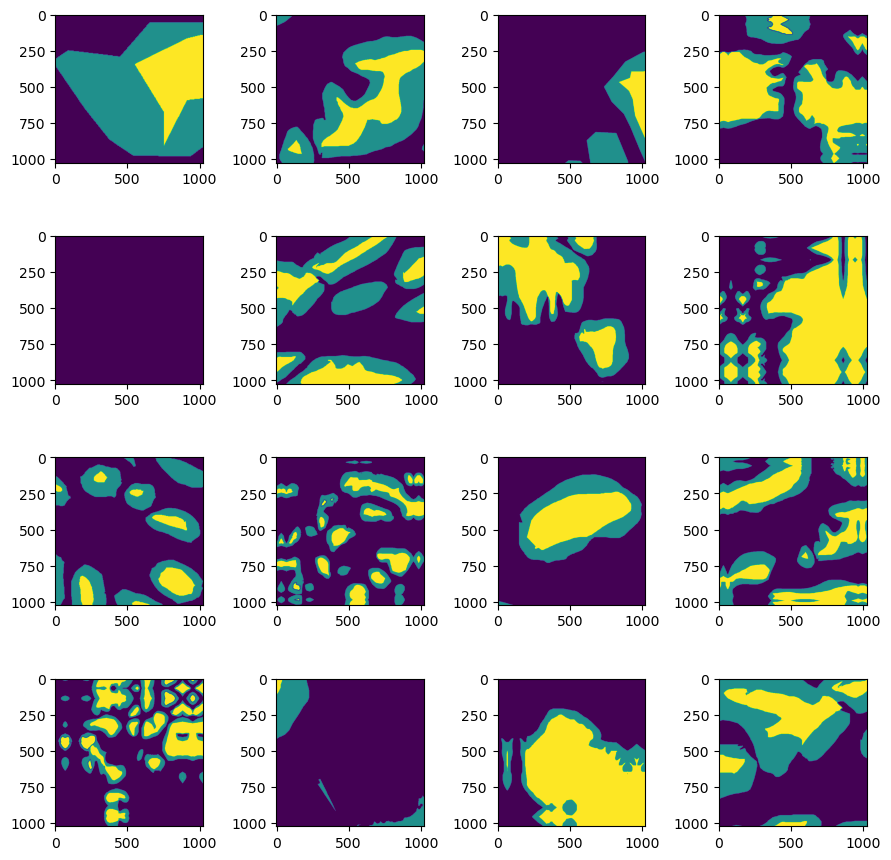

In [6]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(images[k])
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise mask
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(masks[k])
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###